# 06b — LSTM Walk-Forward (Weekly, retrain every 20 steps)

Variant of `06_lstm.ipynb` that **fine-tunes the trained model every 20 test steps**
instead of training once and predicting the full test set in one pass. Same data,
same `MARKET_FEATURES` / `TECH_COLS`, same variant ladder.

**Why this version exists.** With ~330 training sequences, retraining every 4 steps
was tested and severely degraded performance — each fine-tune ran 30 epochs on ~4
new observations, so the gradient updates were mostly noise and the network drifted
away from its tuned configuration (catastrophic forgetting). At 20 steps the fine-tune
sees ~5 months of new data, the number of retrain events drops from ~38 to ~8, and
`FT_EPOCHS=2` keeps the extra training budget small enough that the early-stopped
baseline isn't blown out by unguarded extra epochs.

**Procedure**:
1. Train each variant once on train+val with early stopping (same as `06_lstm.ipynb`).
2. Walk forward through the test set predicting one step at a time.
3. Every `RETRAIN_EVERY = 20` steps, fine-tune the model for `FT_EPOCHS = 2` at
   `LR × 0.3` using **all data up to that point** (train + val + seen test). The
   `StandardScaler` is fixed on train+val to avoid any look-ahead in feature scaling.
4. Resume one-step-ahead prediction with the fine-tuned weights.

**Outputs**:
- `metrics_lstm_weekly_walkforward.csv` (sits next to `metrics_lstm_weekly.csv`)
- `period_lstm_weekly_walkforward.csv`
- Checkpoint files use a `_wf` suffix so the single-train checkpoints aren't overwritten.

**Methodology alignment with RF / XGBoost** (mirrors `06_lstm.ipynb`): same `EXOG`
(silver + 6 cross-asset returns + gs_ratio_z), same 4 tech indicators, parallel
variant ladder including a NonLin variant (squared returns), naïve $y_{t-1}$
baseline included, and a one-shot **hyperparameter grid** (`SEQ_LEN`, `HIDDEN`,
`DROPOUT`) tuned on val loss using the EXOG variant and reused across all variants.
Rolling vs expanding windows not tested — a 100-week rolling LSTM has only ~80
trainable sequences; the walk-forward fine-tune in this notebook is the LSTM-native
equivalent of refitting on recent data.

`EXOG` = weekly silver return + 6 cross-asset returns (gold, USD, copper, S&P500, VIX, oil)
+ gold/silver ratio z-score (level, train-period normalised).

**NonLin features** = squared values of silver return and each cross-asset return —
capture volatility / magnitude information motivated by ARCH-style volatility
clustering. No explicit lag needed (the SEQ_LEN window handles it).

| Variant | Features |
|---|---|
| LSTM-Y | Silver return only |
| LSTM-TECH | Silver + macd\_line, macd\_hist, bb\_bandwidth, silver\_vol\_5w (no cross-assets) |
| LSTM-EXOG | Silver + 6 cross-asset returns + gs\_ratio\_z |
| LSTM-EXOG-NONLIN | EXOG + squared silver return + squared cross-asset returns |
| LSTM-EXOG-TECH | EXOG + tech indicators |
| LSTM-EXOG-REDDIT | EXOG + Reddit sentiment |
| LSTM-EXOG-NEWS | EXOG + news sentiment |
| LSTM-EXOG-SENTIMENT | EXOG + Reddit + news sentiment |
| LSTM-EXOG-TECH-SENTIMENT | EXOG + tech + Reddit + news sentiment |

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import warnings, os, sys
warnings.filterwarnings('ignore')

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
plt.rcParams['figure.dpi'] = 120

DEVICE = 'mps' if torch.backends.mps.is_available() else 'cuda' if torch.cuda.is_available() else 'cpu'
print('Device:', DEVICE)

Device: mps


## 1. Hyperparameters

In [2]:
SEQ_LEN  = 20    # lookback: 20 weeks (~5 months)
HORIZON  = 1     # 1 week ahead
HIDDEN   = 32
N_LAYERS = 1
DROPOUT  = 0.2
EPOCHS   = 150
LR       = 1e-3
PATIENCE = 15
BATCH    = 16    # smaller batch — fewer sequences

# Walk-forward retraining
RETRAIN_EVERY = 20      # fine-tune every N test steps
FT_EPOCHS     = 2       # very low — Stage 1 already found the optimum, just nudge weights
FT_LR_FACTOR  = 0.3     # fine-tune LR = LR * factor

TARGET = 'silver_return'

## 2. Load & aggregate to weekly

In [3]:
# Weekly feature frame (built once by 02_features.ipynb §8 — single source of truth).
weekly = pd.read_csv('../../data/processed/features_weekly.csv', index_col=0, parse_dates=True)

EXOG_RETURNS = ['gold_return', 'usd_return', 'copper_return',
                'sp500_return', 'vix_return', 'oil_return']
EXOG_LEVELS  = ['gs_ratio_z']   # level features — weekly resample uses .last(), not .sum()
EXOG         = EXOG_RETURNS + EXOG_LEVELS
FEAT_COLS    = [TARGET] + EXOG

# Base weekly matrix per split. Features are UN-lagged — the LSTM's SEQ_LEN window supplies
# the 1-week lag (the sequence ending Friday t-1 predicts y_t). Split on the frame's `split`
# column so train/val/test stay separate for sequence building.
def _split(name):
    return weekly[weekly['split'] == name][[TARGET] + EXOG].dropna().copy()
train, val, test = _split('train'), _split('val'), _split('test')

# Sentiment: weekly means from the frame, ffill then 0-fill (the LSTM standardises features).
for df in (train, val, test):
    for col in ['reddit_sentiment', 'news_sentiment']:
        df[col] = weekly[col].reindex(df.index).ffill().fillna(0)

print(f'Train weeks: {len(train)}  Val weeks: {len(val)}  Test weeks: {len(test)}')
print(f'Features: {train.columns.tolist()}')

Train weeks: 365  Val weeks: 52  Test weeks: 174
Features: ['silver_return', 'gold_return', 'usd_return', 'copper_return', 'sp500_return', 'vix_return', 'oil_return', 'gs_ratio_z', 'reddit_sentiment', 'news_sentiment']


In [4]:
# Directional technical indicators — read RAW from the frame (02_features §8 / 02c); the SEQ_LEN
# window supplies the 1-week lag, exactly like the EXOG returns (no pre-shift). 0-filled for
# warmup NaNs. The feature-group registry loaded here is reused by the macro / FRED / COT cells.
import json as _json
with open('../../data/processed/feature_groups.json') as _f:
    GROUPS = _json.load(_f)
TECH_COLS = GROUPS['TECH']
for df in (train, val, test):
    for col in TECH_COLS:
        df[col] = weekly[col].reindex(df.index).fillna(0)
print(f'Technical indicators joined (directional, raw — window lags): {TECH_COLS}')

Technical indicators joined (directional, pre-lagged): ['macd_line', 'macd_hist', 'rsi_14w', 'mom_5w', 'roc_13w', 'roc_26w', 'roc_52w', 'price_ma13w', 'donchian_52w', 'bb_pct_b']


In [5]:
# ── Nonlinear (squared) features ────────────────────────────────────────────
# Squared returns capture magnitude / volatility regardless of sign, motivated
# by ARCH-style volatility clustering. No explicit lag needed: the LSTM's
# SEQ_LEN window provides the temporal lag implicitly — the sequence ending
# Friday t-1 already includes the squared returns at t-SEQ_LEN..t-1 when
# predicting y_t (no week-t value enters the input).
SQ_COLS = []
for col in [TARGET] + EXOG_RETURNS:
    sq_name = f'{col}_sq'
    for df in [train, val, test]:
        df[sq_name] = df[col] ** 2
    SQ_COLS.append(sq_name)

print(f'Nonlinear (squared) features added: {SQ_COLS}')

Nonlinear (squared) features added: ['silver_return_sq', 'gold_return_sq', 'usd_return_sq', 'copper_return_sq', 'sp500_return_sq', 'vix_return_sq', 'oil_return_sq']


In [6]:
# ── Monthly macro: leak-corrected weekly lags from the frame (MACRO group, already lagged) ──
# Level series → back-filled for the 2015 warmup (a 0 would be a wild outlier after
# standardisation). The 2023–2026 test period is fully covered.
MACRO_COLS = GROUPS['MACRO']
for df in (train, val, test):
    for col in MACRO_COLS:
        df[col] = weekly[col].reindex(df.index).ffill().bfill()
print(f'Monthly macro features joined ({len(MACRO_COLS)}): {MACRO_COLS}')

Monthly macro features joined (9): ['cpi_mlag1', 'cpi_mlag2', 'cpi_mlag3', 'fed_funds_mlag1', 'fed_funds_mlag2', 'fed_funds_mlag3', 'ind_prod_mlag1', 'ind_prod_mlag2', 'ind_prod_mlag3']


In [7]:
# ── Daily-FRED changes + COT positioning from the frame (raw weekly, UN-lagged) ──
# The SEQ_LEN window supplies the 1-week lag, same as the EXOG returns. ffill + 0-fill warmup.
def _join_group(cols):
    for df in (train, val, test):
        for col in cols:
            df[col] = weekly[col].reindex(df.index).ffill().fillna(0)
    return list(cols)
FRED_COLS = _join_group(GROUPS['FRED_DAILY'])
COT_COLS  = _join_group(GROUPS['COT'])
print(f'FRED_daily features joined ({len(FRED_COLS)}): {FRED_COLS}')
print(f'COT features joined ({len(COT_COLS)}): {COT_COLS}')

FRED_daily features joined (3): ['real_rates_chg', 'breakeven_chg', 'jobless_chg']
COT features joined (2): ['cot_mm_net_pct', 'cot_comm_net_pct']


## 3. Architecture & helpers

In [8]:
class LSTMForecaster(nn.Module):
    def __init__(self, input_size, hidden_size=32, num_layers=1, dropout=0.2):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers=num_layers,
                            batch_first=True, dropout=dropout)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.lstm(x)
        return self.fc(out[:, -1, :])


def make_sequences(data, seq_len, target_col, horizon=1):
    X, y = [], []
    for i in range(seq_len, len(data) - horizon + 1):
        X.append(data[i - seq_len:i])
        y.append(np.sum(data[i:i + horizon, target_col]))
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)


def run_variant(name, feature_cols):
    print(f'\n{"=" * 50}\nVariant: {name}\n{"=" * 50}')
    cols       = [c for c in feature_cols if c in train.columns]
    target_idx = cols.index(TARGET)

    # Scaler fit on train only — no look-ahead in feature scaling.
    scaler = StandardScaler().fit(train[cols].fillna(0))
    tr_s   = scaler.transform(train[cols].fillna(0))
    va_s   = scaler.transform(val[cols].fillna(0))
    te_s   = scaler.transform(test[cols].fillna(0))

    X_tr, y_tr = make_sequences(tr_s, SEQ_LEN, target_idx, HORIZON)
    X_va, y_va = make_sequences(va_s, SEQ_LEN, target_idx, HORIZON)
    X_te, y_te = make_sequences(te_s, SEQ_LEN, target_idx, HORIZON)
    dates      = test.index[SEQ_LEN:len(test) - HORIZON + 1]

    print(f'  Train seqs: {len(X_tr)}  Val seqs: {len(X_va)}  Test seqs: {len(X_te)}')

    def to_loader(X, y, shuffle=True):
        ds = TensorDataset(torch.tensor(X), torch.tensor(y).unsqueeze(1))
        return DataLoader(ds, batch_size=BATCH, shuffle=shuffle)

    train_loader = to_loader(X_tr, y_tr)
    val_loader   = to_loader(X_va, y_va, shuffle=False)

    safe_name = name.lower().replace("+","_").replace(" ","_")
    ckpt = f'../../data/processed/lstm_{safe_name}_weekly_wf_best.pt'

    model = LSTMForecaster(len(cols), HIDDEN, N_LAYERS, DROPOUT).to(DEVICE)
    opt   = torch.optim.Adam(model.parameters(), lr=LR)
    crit  = nn.MSELoss()
    sched = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, patience=3, factor=0.5)

    # ── Stage 1: initial training with early stopping on val loss ────────────
    best_val, pat_cnt = np.inf, 0
    for epoch in range(1, EPOCHS + 1):
        model.train()
        for xb, yb in train_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            opt.zero_grad()
            loss = crit(model(xb), yb)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()
        model.eval()
        with torch.no_grad():
            vl = np.mean([crit(model(xb.to(DEVICE)), yb.to(DEVICE)).item()
                          for xb, yb in val_loader])
        sched.step(vl)
        if epoch % 25 == 0:
            print(f'  Epoch {epoch:3d}  val={vl:.6f}')
        if vl < best_val:
            best_val, pat_cnt = vl, 0
            torch.save(model.state_dict(), ckpt)
        else:
            pat_cnt += 1
            if pat_cnt >= PATIENCE:
                print(f'  Early stopping at epoch {epoch}')
                break

    model.load_state_dict(torch.load(ckpt))

    # ── Stage 2: walk forward through test set, fine-tuning every RETRAIN_EVERY ──
    # Build the cumulative pool of training sequences (train + val) and grow it
    # as we walk through the test set.
    pool_X = np.concatenate([X_tr, X_va])
    pool_y = np.concatenate([y_tr, y_va])

    preds_s, acts_s = [], []
    n_retrain       = 0

    for i in range(len(X_te)):
        # Predict step i
        model.eval()
        with torch.no_grad():
            xb = torch.tensor(X_te[i:i+1]).to(DEVICE)
            preds_s.append(model(xb).cpu().numpy().flatten()[0])
        acts_s.append(float(y_te[i]))

        # Grow training pool with the just-realised observation
        pool_X = np.concatenate([pool_X, X_te[i:i+1]])
        pool_y = np.concatenate([pool_y, y_te[i:i+1]])

        # Fine-tune every RETRAIN_EVERY steps (skip the final step)
        if (i + 1) % RETRAIN_EVERY == 0 and (i + 1) < len(X_te):
            n_retrain += 1
            ft_opt    = torch.optim.Adam(model.parameters(), lr=LR * FT_LR_FACTOR)
            ft_loader = to_loader(pool_X, pool_y, shuffle=True)
            model.train()
            for _ in range(FT_EPOCHS):
                for xb, yb in ft_loader:
                    xb, yb = xb.to(DEVICE), yb.to(DEVICE)
                    ft_opt.zero_grad()
                    loss = crit(model(xb), yb)
                    loss.backward()
                    nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                    ft_opt.step()

    print(f'  Fine-tune events: {n_retrain} (every {RETRAIN_EVERY} steps)')

    mu, sigma  = scaler.mean_[target_idx], scaler.scale_[target_idx]
    preds      = np.array(preds_s) * sigma + HORIZON * mu
    actuals    = np.array(acts_s)  * sigma + HORIZON * mu

    rmse = np.sqrt(mean_squared_error(actuals, preds))
    mae  = mean_absolute_error(actuals, preds)
    da   = np.mean(np.sign(actuals) == np.sign(preds))
    wda  = np.sum(np.abs(actuals) * (np.sign(actuals) == np.sign(preds))) / np.sum(np.abs(actuals))
    print(f'  RMSE={rmse:.6f}  MAE={mae:.6f}  DA={da:.3f}  WDA={wda:.3f}')
    print(f'  Test sequences: {len(preds)} weekly predictions')

    return {'model': name, 'rmse': rmse, 'mae': mae, 'dir_acc': da, 'wda': wda}, preds, actuals, dates

## 4. Hyperparameter tuning

Mini-grid over `SEQ_LEN`, `HIDDEN`, `DROPOUT` evaluated on the `EXOG` variant
(silver + 6 cross-asset returns) using val loss with early stopping. The best
configuration is then reused across **all** downstream variants — matching the
RF / XGBoost behaviour of tuning the model class once and testing feature
additions on top.

Tuning is on Stage 1 (initial train+val fit) only; the walk-forward fine-tuning
in Stage 2 inherits whatever the tuned architecture is.

In [9]:
from itertools import product

SEQ_GRID     = [10, 20]
HIDDEN_GRID  = [16, 32]
DROPOUT_GRID = [0.1, 0.2, 0.3]

# Tune on the baseline EXOG variant feature set (silver + 6 cross-asset returns).
# Match LSTM-EXOG (returns-only) so tuned hyperparameters apply to the same
# architecture that's evaluated downstream, and to keep the torch RNG state
# aligned with the variant ladder (input_size determines how many random
# numbers the weight init consumes — different size shifts every downstream
# variant's initialisation).
tune_cols = [TARGET] + [c for c in EXOG_RETURNS if c in train.columns]


def eval_config(seq_len, hidden, dropout):
    """Train one LSTM config on train, return best val loss (with early stopping)."""
    scaler_t   = StandardScaler().fit(train[tune_cols].fillna(0))
    tr_s_t     = scaler_t.transform(train[tune_cols].fillna(0))
    va_s_t     = scaler_t.transform(val[tune_cols].fillna(0))
    target_idx = tune_cols.index(TARGET)

    X_tr, y_tr = make_sequences(tr_s_t, seq_len, target_idx, HORIZON)
    X_va, y_va = make_sequences(va_s_t, seq_len, target_idx, HORIZON)
    if len(X_tr) == 0 or len(X_va) == 0:
        return np.inf

    tr_loader = DataLoader(TensorDataset(torch.tensor(X_tr), torch.tensor(y_tr).unsqueeze(1)),
                           batch_size=BATCH, shuffle=True)
    va_loader = DataLoader(TensorDataset(torch.tensor(X_va), torch.tensor(y_va).unsqueeze(1)),
                           batch_size=BATCH, shuffle=False)

    model = LSTMForecaster(len(tune_cols), hidden, N_LAYERS, dropout).to(DEVICE)
    opt   = torch.optim.Adam(model.parameters(), lr=LR)
    crit  = nn.MSELoss()

    best_vl, pat = np.inf, 0
    for _ in range(EPOCHS):
        model.train()
        for xb, yb in tr_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            opt.zero_grad()
            loss = crit(model(xb), yb)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()
        model.eval()
        with torch.no_grad():
            vl = np.mean([crit(model(xb.to(DEVICE)), yb.to(DEVICE)).item()
                          for xb, yb in va_loader])
        if vl < best_vl:
            best_vl, pat = vl, 0
        else:
            pat += 1
            if pat >= PATIENCE:
                break
    return best_vl


configs = list(product(SEQ_GRID, HIDDEN_GRID, DROPOUT_GRID))
print(f'Tuning on EXOG variant ({len(tune_cols)} features) — {len(configs)} configs')
print('-' * 60)

search = []
for seq_len, hidden, dropout in configs:
    vl = eval_config(seq_len, hidden, dropout)
    print(f'  SEQ_LEN={seq_len:>3}  HIDDEN={hidden:>3}  DROPOUT={dropout}  val_loss={vl:.6f}')
    search.append({'seq_len': seq_len, 'hidden': hidden,
                   'dropout': dropout, 'val_loss': vl})

best = min(search, key=lambda r: r['val_loss'])
print(f'\nBest:  SEQ_LEN={best["seq_len"]}  HIDDEN={best["hidden"]}'
      f'  DROPOUT={best["dropout"]}  val_loss={best["val_loss"]:.6f}')

# Override the defaults from Section 1 with the tuned values
SEQ_LEN, HIDDEN, DROPOUT = best['seq_len'], best['hidden'], best['dropout']

Tuning on EXOG variant (7 features) — 12 configs
------------------------------------------------------------


  SEQ_LEN= 10  HIDDEN= 16  DROPOUT=0.1  val_loss=1.384054


  SEQ_LEN= 10  HIDDEN= 16  DROPOUT=0.2  val_loss=1.408274


  SEQ_LEN= 10  HIDDEN= 16  DROPOUT=0.3  val_loss=1.367145


  SEQ_LEN= 10  HIDDEN= 32  DROPOUT=0.1  val_loss=1.436820


...

  SEQ_LEN= 20  HIDDEN= 16  DROPOUT=0.2  val_loss=1.572845


  SEQ_LEN= 20  HIDDEN= 16  DROPOUT=0.3  val_loss=1.562595


  SEQ_LEN= 20  HIDDEN= 32  DROPOUT=0.1  val_loss=1.509120


  SEQ_LEN= 20  HIDDEN= 32  DROPOUT=0.2  val_loss=1.524490


  SEQ_LEN= 20  HIDDEN= 32  DROPOUT=0.3  val_loss=1.517482

Best:  SEQ_LEN=10  HIDDEN=16  DROPOUT=0.3  val_loss=1.367145


## 5. Train variants

In [10]:
# Baseline EXOG = silver_return + cross-asset returns (no gs_ratio_z, no NonLin).
# gs_ratio_z and squared returns are treated as separate feature groups tested
# in the ablation variants below.
MARKET_FEATURES = [TARGET] + [c for c in EXOG_RETURNS if c in train.columns]
GS_FEATURES     = [c for c in EXOG_LEVELS  if c in train.columns]
SENT_FEATURES   = ['reddit_sentiment', 'news_sentiment']

variants = {
    'LSTM-Y':                       [TARGET],
    'LSTM-TECH':                    [TARGET] + TECH_COLS,
    'LSTM-EXOG':                    MARKET_FEATURES,
    'LSTM-EXOG-GS':                 MARKET_FEATURES + GS_FEATURES,
    'LSTM-EXOG-NONLIN':             MARKET_FEATURES + SQ_COLS,
    'LSTM-EXOG-TECH':               MARKET_FEATURES + TECH_COLS,
    'LSTM-EXOG-REDDIT':             MARKET_FEATURES + ['reddit_sentiment'],
    'LSTM-EXOG-NEWS':               MARKET_FEATURES + ['news_sentiment'],
    'LSTM-EXOG-SENTIMENT':          MARKET_FEATURES + SENT_FEATURES,
    'LSTM-EXOG-GS-SENTIMENT':       MARKET_FEATURES + GS_FEATURES + SENT_FEATURES,
    'LSTM-EXOG-NONLIN-SENTIMENT':   MARKET_FEATURES + SQ_COLS + SENT_FEATURES,
    'LSTM-EXOG-TECH-SENTIMENT':     MARKET_FEATURES + TECH_COLS + SENT_FEATURES,
    # Kitchen sink: gs_z + NonLin + Tech + Sentiment
    'LSTM-EXOG-ALL':                MARKET_FEATURES + GS_FEATURES + SQ_COLS + TECH_COLS + SENT_FEATURES,
}

# Monthly macro ablation rung (raw leak-corrected lags from 02_features §8, was 02d). Appended at the
# END of the ladder on purpose: each run_variant() call consumes torch RNG (weight
# init, Stage-1 training, Stage-2 fine-tuning), so inserting mid-dict would shift
# every later variant and change its result. Appending leaves all existing
# variants bit-identical. The MACRO group is always present in the frame, so it
# can't silently duplicate LSTM-EXOG.
if MACRO_COLS:
    variants['LSTM-EXOG-MACRO'] = MARKET_FEATURES + MACRO_COLS

# Daily-FRED + COT public-info rungs (feature_groups.json), appended for the same
# RNG reason as LSTM-EXOG-MACRO above — keeps all earlier variants bit-identical.
# Left out of LSTM-EXOG-ALL on purpose: editing ALL (mid-ladder) would shift RNG.
if FRED_COLS:
    variants['LSTM-EXOG-FRED'] = MARKET_FEATURES + FRED_COLS
if COT_COLS:
    variants['LSTM-EXOG-COT'] = MARKET_FEATURES + COT_COLS
if FRED_COLS and COT_COLS:
    variants['LSTM-EXOG-FRED-COT'] = MARKET_FEATURES + FRED_COLS + COT_COLS

results     = {}
all_preds   = {}
actuals_arr = None
dates_arr   = None

for name, cols in variants.items():
    m, preds, acts, dates = run_variant(name, cols)
    results[name]   = m
    all_preds[name] = preds
    actuals_arr     = acts
    dates_arr       = dates


Variant: LSTM-Y
  Train seqs: 355  Val seqs: 42  Test seqs: 164


  Early stopping at epoch 21


  Fine-tune events: 8 (every 20 steps)
  RMSE=0.053001  MAE=0.037955  DA=0.573  WDA=0.576
  Test sequences: 164 weekly predictions

Variant: LSTM-TECH
  Train seqs: 355  Val seqs: 42  Test seqs: 164


  Early stopping at epoch 20


  Fine-tune events: 8 (every 20 steps)
  RMSE=0.053206  MAE=0.038355  DA=0.506  WDA=0.503
  Test sequences: 164 weekly predictions

Variant: LSTM-EXOG
  Train seqs: 355  Val seqs: 42  Test seqs: 164


...

  Fine-tune events: 8 (every 20 steps)
  RMSE=0.052986  MAE=0.038066  DA=0.543  WDA=0.631
  Test sequences: 164 weekly predictions

Variant: LSTM-EXOG-COT
  Train seqs: 355  Val seqs: 42  Test seqs: 164


  Early stopping at epoch 19


  Fine-tune events: 8 (every 20 steps)
  RMSE=0.052956  MAE=0.038155  DA=0.530  WDA=0.589
  Test sequences: 164 weekly predictions

Variant: LSTM-EXOG-FRED-COT
  Train seqs: 355  Val seqs: 42  Test seqs: 164


  Early stopping at epoch 16


  Fine-tune events: 8 (every 20 steps)
  RMSE=0.053171  MAE=0.038137  DA=0.537  WDA=0.559
  Test sequences: 164 weekly predictions


## 6. Results

In [11]:
# Naive baseline: predict y_t = y_{t-1}.
naive_pred = np.concatenate([[np.nan], actuals_arr[:-1]])
mask       = ~np.isnan(naive_pred)
n_acts     = actuals_arr[mask]
n_preds    = naive_pred[mask]

naive_row = {
    'model':   'Naive (t-1 week)',
    'rmse':    float(np.sqrt(mean_squared_error(n_acts, n_preds))),
    'mae':     float(mean_absolute_error(n_acts, n_preds)),
    'dir_acc': float(np.mean(np.sign(n_acts) == np.sign(n_preds))),
    'wda':     float(np.sum(np.abs(n_acts) * (np.sign(n_acts) == np.sign(n_preds))) / np.sum(np.abs(n_acts))),
}

metrics_df = pd.DataFrame([naive_row] + list(results.values()))
metrics_df.to_csv('../../data/processed/metrics_lstm_weekly_walkforward.csv', index=False)

print(f'{"Model":<30}  {"RMSE":>10}  {"MAE":>10}  {"DA":>6}  {"WDA":>6}')
print('-' * 68)
for _, row in metrics_df.iterrows():
    print(f'{row["model"]:<30}  {row["rmse"]:>10.6f}  {row["mae"]:>10.6f}'
          f'  {row["dir_acc"]:>6.3f}  {row["wda"]:>6.3f}')

Model                                 RMSE         MAE      DA     WDA
--------------------------------------------------------------------
Naive (t-1 week)                  0.077178    0.054864   0.491   0.493
LSTM-Y                            0.053001    0.037955   0.573   0.576
LSTM-TECH                         0.053206    0.038355   0.506   0.503
LSTM-EXOG                         0.052951    0.037999   0.591   0.621
LSTM-EXOG-GS                      0.053014    0.038013   0.591   0.590
LSTM-EXOG-NONLIN                  0.052856    0.038190   0.518   0.583
LSTM-EXOG-TECH                    0.053609    0.038499   0.463   0.427
LSTM-EXOG-REDDIT                  0.053141    0.038267   0.494   0.511
LSTM-EXOG-NEWS                    0.053070    0.038046   0.555   0.592
LSTM-EXOG-SENTIMENT               0.053239    0.038323   0.506   0.557
LSTM-EXOG-GS-SENTIMENT            0.052808    0.037756   0.549   0.561
LSTM-EXOG-NONLIN-SENTIMENT        0.054042    0.038682   0.488   0.464
LSTM-EXO

## 7. Period breakdown

In [12]:
sys.path.insert(0, os.path.abspath('../../src'))
from eval_utils import period_metrics, diebold_mariano, PERIODS

best_name = max(results, key=lambda k: results[k]['wda'])
best_pred = all_preds[best_name]
print('Best variant by WDA:', best_name)

res = period_metrics(actuals_arr, best_pred, dates_arr, PERIODS)
display(res[['n', 'DA', 'WDA']].style
        .format({'n': '{:.0f}', 'DA': '{:.3f}', 'WDA': '{:.3f}'})
        .background_gradient(cmap='RdYlGn', subset=['DA', 'WDA'], vmin=0.35, vmax=0.65))
res[['n', 'DA', 'WDA']].to_csv('../../data/processed/period_lstm_weekly_walkforward.csv')

# Save winning variant predictions for cross-model DM tests in evaluation.ipynb
pd.DataFrame({'actual': actuals_arr, 'predicted': best_pred},
             index=pd.DatetimeIndex(dates_arr))\
  .rename_axis('Date').to_csv('../../data/processed/preds_lstm_walkforward_best_weekly.csv')
print(f'Saved winning-variant predictions: preds_lstm_walkforward_best_weekly.csv  ({best_name})')

Best variant by WDA: LSTM-EXOG-FRED


,n,DA,WDA
Period,,,
2023 (choppy),42,0.524,0.547
2024 (bull start),52,0.462,0.470
2025 (bull run),52,0.577,0.696
2026 (YTD),18,0.722,0.808
── Full test ──,164,0.543,0.631


Saved winning-variant predictions: preds_lstm_walkforward_best_weekly.csv  (LSTM-EXOG-FRED)


## 8. Diebold-Mariano tests

Tests whether each variant produces statistically significant forecast improvements
over the LSTM-EXOG baseline (market features only).
H0: equal predictive accuracy (squared error loss). p < 0.05 = significant improvement.

In [13]:
print("Diebold-Mariano tests — each variant vs LSTM-EXOG baseline")
print("H0: equal predictive accuracy  |  * p<0.05  ** p<0.01  *** p<0.001  ns=not significant")
print("-" * 90)

baseline_key  = 'LSTM-EXOG'
baseline_pred = all_preds[baseline_key]
for name, pred in all_preds.items():
    if name == baseline_key:
        continue
    diebold_mariano(actuals_arr, baseline_pred, pred, baseline_key, name)

Diebold-Mariano tests — each variant vs LSTM-EXOG baseline
H0: equal predictive accuracy  |  * p<0.05  ** p<0.01  *** p<0.001  ns=not significant
------------------------------------------------------------------------------------------
LSTM-EXOG                                vs LSTM-Y                                    DM=-0.280  p=0.779  (ns)  -> winner: tie
LSTM-EXOG                                vs LSTM-TECH                                 DM=-0.903  p=0.367  (ns)  -> winner: tie
LSTM-EXOG                                vs LSTM-EXOG-GS                              DM=-0.180  p=0.857  (ns)  -> winner: tie
LSTM-EXOG                                vs LSTM-EXOG-NONLIN                          DM=+0.428  p=0.669  (ns)  -> winner: tie
LSTM-EXOG                                vs LSTM-EXOG-TECH                            DM=-2.171  p=0.030  *     -> winner: LSTM-EXOG
LSTM-EXOG                                vs LSTM-EXOG-REDDIT                          DM=-0.956  p=0.339  (ns)  -> winner:

## 9. 2026 zoom — actual vs best variant

Focuses on the most recent out-of-sample weeks where silver has been most active.
Uses the best-performing LSTM variant by WDA (same `best_name` / `best_pred`
as the sub-period breakdown).

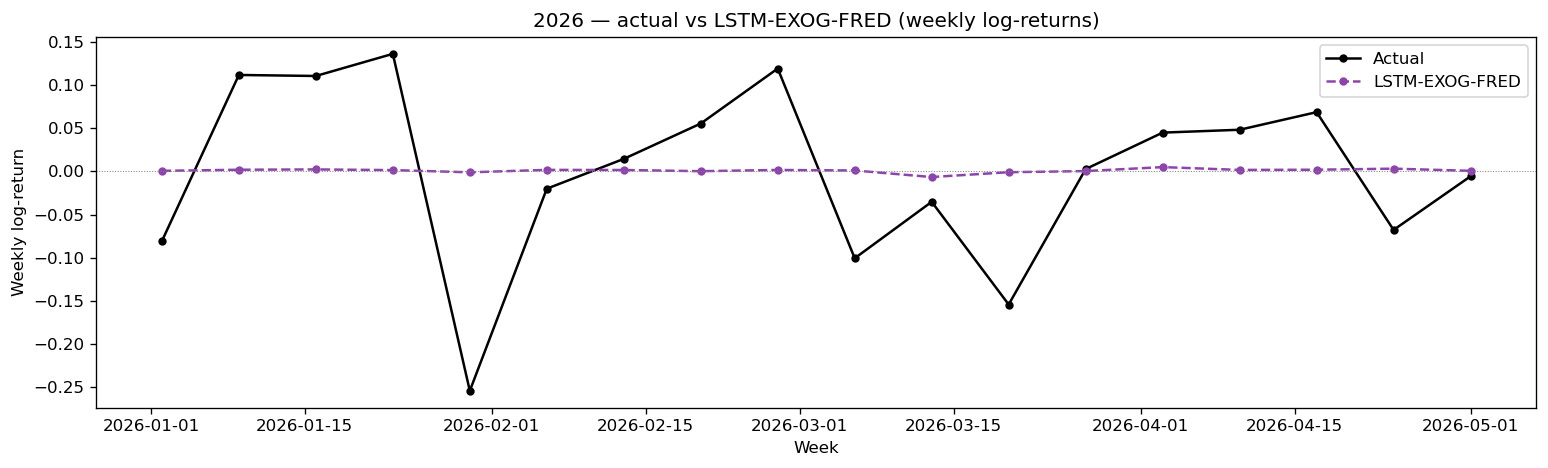

In [14]:
df26 = pd.DataFrame({"actual": actuals_arr, "pred": best_pred},
                    index=pd.DatetimeIndex(dates_arr))
df26 = df26.loc["2026":]

if df26.empty:
    print("No 2026 data in test set yet.")
else:
    fig, ax = plt.subplots(figsize=(13, 4))
    ax.plot(df26.index, df26["actual"], color="black",  lw=1.5, marker="o", ms=4, label="Actual")
    ax.plot(df26.index, df26["pred"],   color="#8e44ad", lw=1.5, marker="o", ms=4,
            ls="--", label=f"{best_name}")
    ax.axhline(0, color="grey", lw=0.6, ls=":")
    ax.set_title(f"2026 — actual vs {best_name} (weekly log-returns)", fontsize=12)
    ax.set_ylabel("Weekly log-return")
    ax.set_xlabel("Week")
    ax.legend()
    plt.tight_layout()
    plt.show()